# Análisis Predictivo - Evaluación 3

El archivo que se le suministra es un conjunto de datos de pacientes con cáncer de mama se obtuvo de la actualización de noviembre de 2017 del Programa SEER del NCI, que proporciona información sobre estadísticas de cáncer basadas en la población. El conjunto de datos incluyó a pacientes de sexo femenino con cáncer de mama de carcinoma lobular y ductal infiltrante (códigos histológicos 8522/3 de recodificación NOS de citas primarias del SEER) diagnosticado entre 2006 y 2010.

Las variables que contiene este dataset son:

1. Age: Se refiere a la edad del paciente en el momento del diagnóstico.
2. Race: raza o etnia del paciente.
3. Marital Status: El estado civil del paciente (casado, soltero, divorciado, etc.).
4. T Stage: La clasificación del tamaño o extensión del tumor primario (normalmente se utiliza en el sistema TNM).
5. N Stage: Se refiere a la extensión del cáncer a los ganglios linfáticos cercanos.
6. 6th State: Puede referirse al estadio del cáncer según una clasificación específica (como la clasificación AJCC).
7. differentiate: Se refiere al grado de diferenciación celular del tumor (lo diferentes que son las células tumorales de las células normales), un factor utilizado para determinar la agresividad del cáncer.
8. Grade: Se refiere al grado de progresión del tumor o cáncer y a cuánto se ha extendido.
9. A Stage: Puede referirse a un estadio específico en la clasificación por estadios del cáncer.
10. Tumor Size: El tamaño medido del tumor primario.
11. Estrogen Status: Estado de los receptores de estrógenos en las células cancerosas (positivo o negativo), que afecta al tratamiento.
12. Progesterone Status: Estado de los receptores de progesterona en las células cancerosas (positivo o negativo).
13. Regional Node Examined: El número de ganglios linfáticos examinados para detectar la propagación del cáncer.
14. Reginol Node Positive: El número de ganglios linfáticos que dieron positivo para el cáncer.
15. Survival Monyhs: El número de meses que el paciente estuvo vivo después del diagnóstico.
16. Status: El estado final del paciente (como supervivencia o muerte).

#### <span style="color:green"> Neithan Felipe Gomez Rivera - 1013338680



Se creo un modelo de regresión logística para predecir la variable **Status**, con los siguientes resultados:

```
                precision    recall  f1-score   support

       Alive       0.95      0.81      0.88       678
        Dead       0.42      0.76      0.54       121

    accuracy                           0.80       799
   macro avg       0.69      0.79      0.71       799
weighted avg       0.87      0.80      0.83       799

```

# Parte 1

Haga un modelo de bosque aleatorio para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-macro score del modelo de regresión logísitca. Así:
- Si el f1-macro obtenido es menor a 0.71, la máxima nota que obtendrá es 3.0.
- Si el f1-macro obtenido es menor a 0.74, la máxima nota que obtendrá es 4.0.
- Si el f1-macro obtenido es menor a 0.76, la máxima nota que obtendrá es 4.5.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer

file_path = 'Breast_Cancer_dataset.csv' 

df = pd.read_csv(file_path,
    na_values=[' ',' -  ', 'nan', 'NaN', 'NA', 'n/a', 'N/A', 'na', '--'],
    sep=';'
) 

# Daba errores de nulos en la matriz de confusion y en el entrenamiento pese a ser random Tree
df = df.dropna(subset=['Status'])

In [2]:
X = df.drop(columns=['Status'])
y = df['Status']

le = LabelEncoder()
y = le.fit_transform(y) 

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import TargetEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', TargetEncoder(random_state=1), cat_cols)
    ],
    remainder='passthrough' 
)

In [4]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=1, class_weight='balanced'))
])

param_grid_rf = {
    'classifier__n_estimators': [150, 200, 300],       
    'classifier__max_depth': [10, 15, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2, 4]
}

In [5]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'classifier__max_depth': [10, 15, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [150, 200, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [6]:
print("RESULTADOS SINTONIZACIÓN")
print(f"Mejor validación : {grid_rf.best_score_:.4f}")
print("Mejores hiperparámetros:\n")
for k, v in grid_rf.best_params_.items():
    print(f"{k}: {v}")
    
best_rf = grid_rf.best_estimator_
print(f"Score Entrenamiento: {best_rf.score(X_train, y_train):.4f}")
print(f"Score Prueba: {best_rf.score(X_test, y_test):.4f}\n")

RESULTADOS SINTONIZACIÓN
Mejor validación : 0.7938
Mejores hiperparámetros:

classifier__max_depth: 20
classifier__min_samples_leaf: 2
classifier__min_samples_split: 2
classifier__n_estimators: 200
Score Entrenamiento: 0.9360
Score Prueba: 0.8976



In [7]:
y_pred_rf = best_rf.predict(X_test)
print("REPORTE DE CLASIFICACIÓN")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

       Alive       0.92      0.96      0.94       680
        Dead       0.70      0.56      0.62       121

    accuracy                           0.90       801
   macro avg       0.81      0.76      0.78       801
weighted avg       0.89      0.90      0.89       801



MATRIZ DE CONFUSIÓN


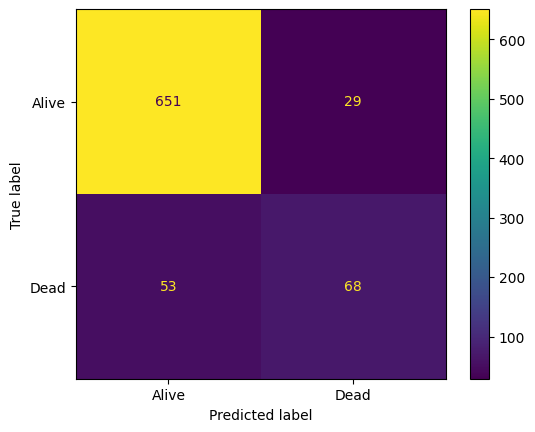

In [8]:
print("MATRIZ DE CONFUSIÓN")
ConfusionMatrixDisplay.from_estimator(
    grid_rf.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
)

In [9]:
importances_rf = best_rf.named_steps['classifier'].feature_importances_
features_rf = best_rf.named_steps['preprocessor'].get_feature_names_out()

df_importances_rf = pd.DataFrame({
    'Feature': features_rf,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n IMPORTANCIA DE CARACTERÍSTICAS")
print(df_importances_rf)


 IMPORTANCIA DE CARACTERÍSTICAS
                              Feature  Importance
0          remainder__Survival Months    0.362296
1                      remainder__Age    0.086397
2               remainder__Tumor Size    0.074108
3   remainder__Regional Node Examined    0.069256
4    remainder__Reginol Node Positive    0.063423
5                      cat__6th Stage    0.049322
6                        cat__N Stage    0.045874
7                 cat__Marital Status    0.042611
8                          cat__Grade    0.035113
9                  cat__differentiate    0.034991
10                      cat__T Stage     0.034677
11           cat__Progesterone Status    0.033661
12                          cat__Race    0.029175
13               cat__Estrogen Status    0.024857
14                       cat__A Stage    0.014240


# Parte 2
 
Haga un modelo de boosting para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-macro score del modelo de regresión logísitca. Así:
- Si el f1-macro obtenido es menor a 0.75, la máxima nota que obtendrá es 3.0.
- Si el f1-macro obtenido es menor a 0.77, la máxima nota que obtendrá es 4.0.
- Si el f1-macro obtenido es menor a 0.79, la máxima nota que obtendrá es 4.5.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) 
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor_lgb = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

In [11]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lgb),
    ('classifier', LGBMClassifier(random_state=1, verbose=-1))
])
param_grid_lgb = {
    'classifier__n_estimators': [100, 150, 200],       
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__max_depth': [4, 6, 8],
    'classifier__num_leaves': [15, 31, 50],
    'classifier__min_child_samples': [10, 20]
}

In [12]:
grid_lgb = GridSearchCV(
    estimator=lgb_pipeline,
    param_grid=param_grid_lgb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_lgb.fit(X_train, y_train)

,estimator,Pipeline(step...verbose=-1))])
,param_grid,"{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [4, 6, ...], 'classifier__min_child_samples': [10, 20], 'classifier__n_estimators': [100, 150, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [13]:
print("RESULTADOS SINTONIZACIÓN")
print(f"Mejor validación: {grid_lgb.best_score_:.4f}")
print("Mejores hiperparámetros:\n")
for k, v in grid_lgb.best_params_.items():
    print(f"{k}: {v}")

best_lgb = grid_lgb.best_estimator_
print(f"Score Entrenamiento: {best_lgb.score(X_train, y_train):.4f}")
print(f"Score Prueba: {best_lgb.score(X_test, y_test):.4f}\n")

RESULTADOS SINTONIZACIÓN
Mejor validación: 0.7831
Mejores hiperparámetros:

classifier__learning_rate: 0.03
classifier__max_depth: 6
classifier__min_child_samples: 10
classifier__n_estimators: 100
classifier__num_leaves: 15
Score Entrenamiento: 0.9207
Score Prueba: 0.9064



c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
y_pred_lgb = best_lgb.predict(X_test)
print("REPORTE CLASIFICACIÓN")
print(classification_report(y_test, y_pred_lgb, target_names=le.classes_))

REPORTE CLASIFICACIÓN
              precision    recall  f1-score   support

       Alive       0.92      0.97      0.95       680
        Dead       0.79      0.52      0.63       121

    accuracy                           0.91       801
   macro avg       0.85      0.75      0.79       801
weighted avg       0.90      0.91      0.90       801



c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


MATRIZ DE CONFUSIÓN


c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


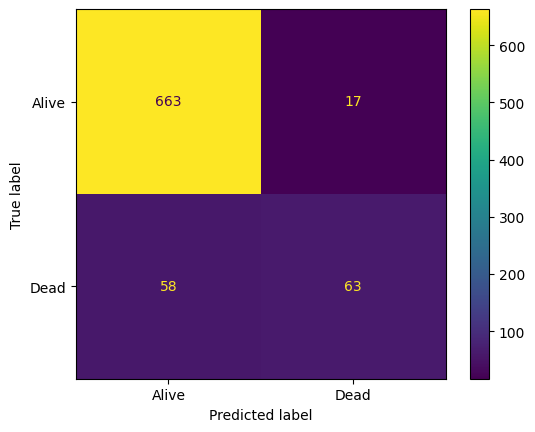

In [15]:
print("MATRIZ DE CONFUSIÓN")
ConfusionMatrixDisplay.from_estimator(
    grid_lgb.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
)

In [16]:
importances_lgb = best_lgb.named_steps['classifier'].feature_importances_
features_lgb = best_lgb.named_steps['preprocessor'].get_feature_names_out()

df_importances_lgb = pd.DataFrame({
    'Feature': features_lgb,
    'Importance': importances_lgb
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\nIMPORTANCIA DE CARACTERÍSTICAS")
print(df_importances_lgb)


IMPORTANCIA DE CARACTERÍSTICAS
                                     Feature  Importance
0                       num__Survival Months         380
1                                   num__Age         236
2                 num__Reginol Node Positive         228
3                num__Regional Node Examined         155
4                            num__Tumor Size         114
5   cat__differentiate_Poorly differentiated          63
6          cat__Progesterone Status_Positive          53
7                cat__Marital Status_Married          42
8              cat__Estrogen Status_Positive          31
9     cat__differentiate_Well differentiated          25
10             cat__Marital Status_Separated          13
11                          cat__T Stage _T4          12
12                          cat__T Stage _T2           9
13                        cat__6th Stage_IIB           9
14                           cat__Race_White           6
15                           cat__Race_Other           6

# Condiciones de entrega de la evaluación:

- Debe entregar un archivo en formato .ipynb. No se admiten URLs.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura (código redundante, funciones innecesarias, versiones preliminares de modelos). Solo entregue el código que de respuesta a lo que se le pide que haga.